In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load Dataset
df = pd.read_csv("india_housing_prices.csv")


In [53]:
print(df.head())

   ID        State      City      Locality      Property_Type  BHK  Area  \
0   1   Tamil Nadu   Chennai   Locality_84          Apartment    1  4740   
1   2  Maharashtra      Pune  Locality_490  Independent House    3  2364   
2   3       Punjab  Ludhiana  Locality_167          Apartment    2  3642   
3   4    Rajasthan   Jodhpur  Locality_393  Independent House    2  2741   
4   5    Rajasthan    Jaipur  Locality_466              Villa    4  4823   

    Price  Price_per_SqFt  Year_Built  ... Nearby_Schools  Nearby_Hospitals  \
0  489.76    10332.489451        1990  ...             10                 3   
1  195.52     8270.727580        2008  ...              8                 1   
2  183.79     5046.403075        1997  ...              9                 8   
3  300.29    10955.490697        1991  ...              5                 7   
4  182.90     3792.245490        2002  ...              4                 9   

   Public_Transport_Accessibility  Parking_Space  Security  \
0     

In [54]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   ID                              250000 non-null  int64   
 1   State                           250000 non-null  object  
 2   City                            250000 non-null  object  
 3   Locality                        250000 non-null  object  
 4   Property_Type                   250000 non-null  object  
 5   BHK                             250000 non-null  int64   
 6   Area                            250000 non-null  int64   
 7   Price                           250000 non-null  float64 
 8   Price_per_SqFt                  250000 non-null  float64 
 9   Year_Built                      250000 non-null  int64   
 10  Furnished_Status                250000 non-null  object  
 11  Floor_No                        250000 non-null  int64   
 12  To

In [55]:
# Rename for simplicity
df.rename(columns={
    "Size_in_SqFt": "Area",
    "Price_in_Lakhs": "Price"
}, inplace=True)

#  DATA CLEANING

In [56]:
# Fill missing numeric values
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [57]:
# Fill missing numeric values
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [58]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [59]:
# Create derived fields
df["Price_per_SqFt"] = df["Price"] * 100000 / df["Area"]

df["Age_Range"] = pd.cut(df["Age_of_Property"],
                         bins=[0, 5, 10, 20, 50],
                         labels=["0–5", "6–10", "11–20", "20+"])


# Exploratory Data Analysis (EDA)

#  Price & Size Analysis


Text(0.5, 1.0, 'Price Distribution (Lakhs)')

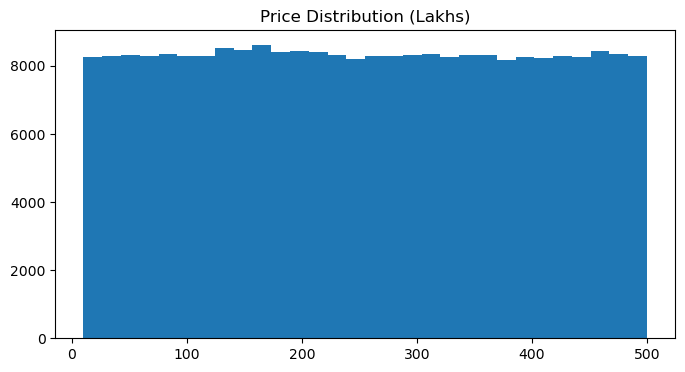

In [60]:
# 1. Price Distribution
plt.figure(figsize=(8,4))
plt.hist(df["Price"], bins=30)
plt.title("Price Distribution (Lakhs)")


Text(0.5, 1.0, 'Area (SqFt)')

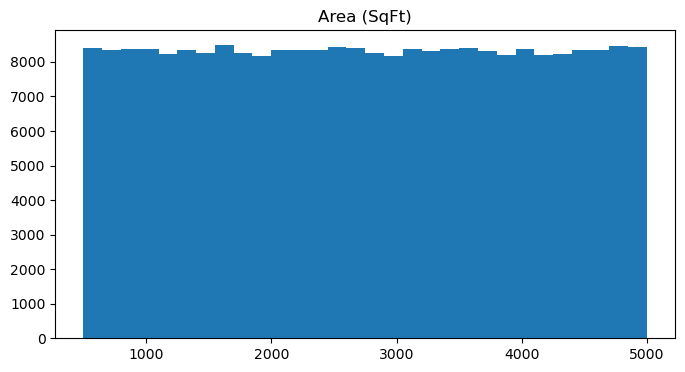

In [61]:
# 2. Area Distribution
plt.figure(figsize=(8,4))
plt.hist(df["Area"], bins=30)
plt.title("Area (SqFt)")


(array([0, 1, 2]),
 [Text(0, 0, 'Apartment'),
  Text(1, 0, 'Independent House'),
  Text(2, 0, 'Villa')])

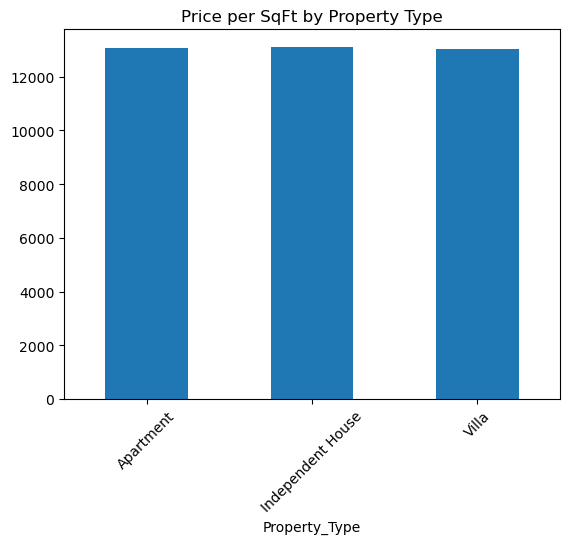

In [62]:
# 3. Price per SqFt by Property Type
df.groupby("Property_Type")["Price_per_SqFt"].mean().plot(kind="bar")
plt.title("Price per SqFt by Property Type")
plt.xticks(rotation=45)


Text(0, 0.5, 'Price (Lakhs)')

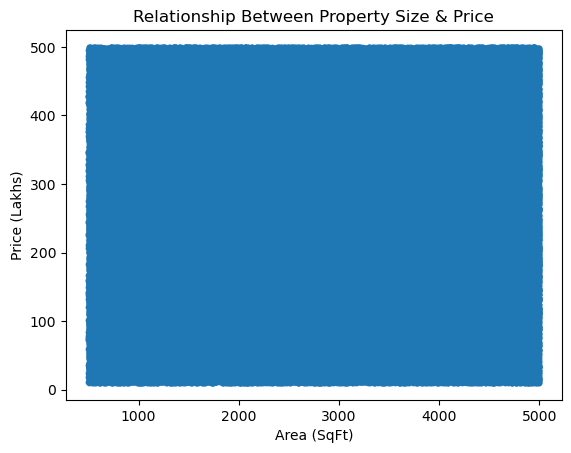

In [63]:
# 4. Size vs Price Scatter
plt.scatter(df["Area"], df["Price"], s=10)
plt.title("Relationship Between Property Size & Price")
plt.xlabel("Area (SqFt)")
plt.ylabel("Price (Lakhs)")



Text(0.5, 1.0, 'Outliers in Price per SqFt')

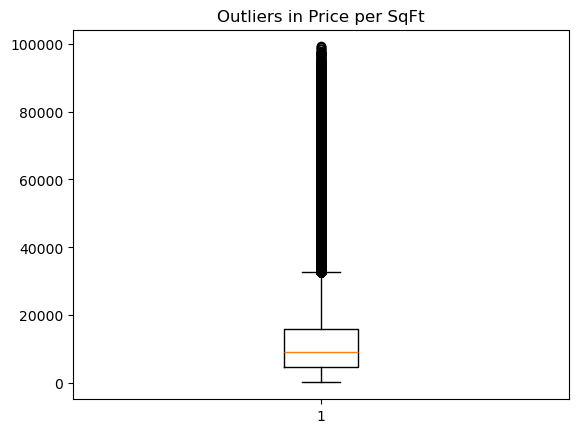

In [64]:
# 5. Outlier Check – Price per SqFt
plt.boxplot(df["Price_per_SqFt"])
plt.title("Outliers in Price per SqFt")


# Location-Based Analysis

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 [Text(0, 0, 'Andhra Pradesh'),
  Text(1, 0, 'Assam'),
  Text(2, 0, 'Bihar'),
  Text(3, 0, 'Chhattisgarh'),
  Text(4, 0, 'Delhi'),
  Text(5, 0, 'Gujarat'),
  Text(6, 0, 'Haryana'),
  Text(7, 0, 'Jharkhand'),
  Text(8, 0, 'Karnataka'),
  Text(9, 0, 'Kerala'),
  Text(10, 0, 'Madhya Pradesh'),
  Text(11, 0, 'Maharashtra'),
  Text(12, 0, 'Odisha'),
  Text(13, 0, 'Punjab'),
  Text(14, 0, 'Rajasthan'),
  Text(15, 0, 'Tamil Nadu'),
  Text(16, 0, 'Telangana'),
  Text(17, 0, 'Uttar Pradesh'),
  Text(18, 0, 'Uttarakhand'),
  Text(19, 0, 'West Bengal')])

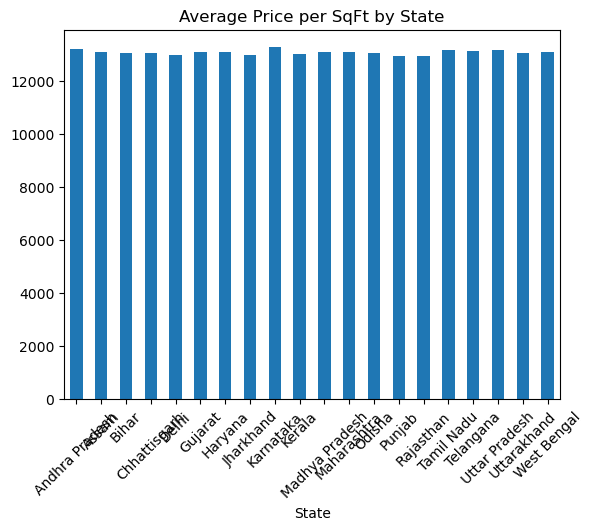

In [65]:
# 6. Avg Price per SqFt by State
df.groupby("State")["Price_per_SqFt"].mean().plot(kind="bar")
plt.title("Average Price per SqFt by State")
plt.xticks(rotation=45)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41]),
 [Text(0, 0, 'Ahmedabad'),
  Text(1, 0, 'Amritsar'),
  Text(2, 0, 'Bangalore'),
  Text(3, 0, 'Bhopal'),
  Text(4, 0, 'Bhubaneswar'),
  Text(5, 0, 'Bilaspur'),
  Text(6, 0, 'Chennai'),
  Text(7, 0, 'Coimbatore'),
  Text(8, 0, 'Cuttack'),
  Text(9, 0, 'Dehradun'),
  Text(10, 0, 'Durgapur'),
  Text(11, 0, 'Dwarka'),
  Text(12, 0, 'Faridabad'),
  Text(13, 0, 'Gaya'),
  Text(14, 0, 'Gurgaon'),
  Text(15, 0, 'Guwahati'),
  Text(16, 0, 'Haridwar'),
  Text(17, 0, 'Hyderabad'),
  Text(18, 0, 'Indore'),
  Text(19, 0, 'Jaipur'),
  Text(20, 0, 'Jamshedpur'),
  Text(21, 0, 'Jodhpur'),
  Text(22, 0, 'Kochi'),
  Text(23, 0, 'Kolkata'),
  Text(24, 0, 'Lucknow'),
  Text(25, 0, 'Ludhiana'),
  Text(26, 0, 'Mangalore'),
  Text(27, 0, 'Mumbai'),
  Text(28, 0, 'Mysore'),
  Text(29, 0, 'Nagpur'),
  Text(30, 0, 'New De

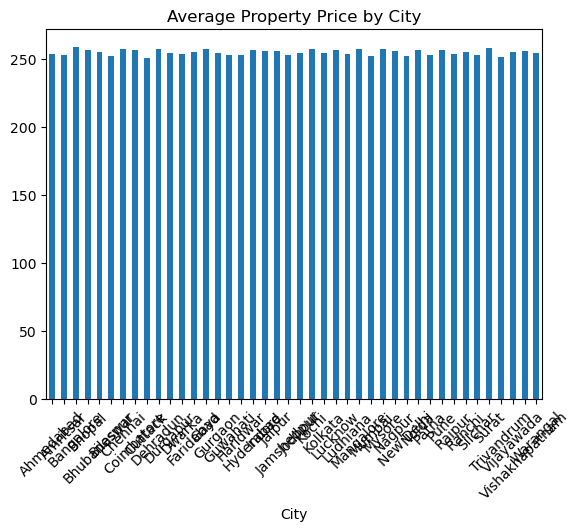

In [66]:
# 7. Avg Property Price by City
df.groupby("City")["Price"].mean().plot(kind="bar")
plt.title("Average Property Price by City")
plt.xticks(rotation=45)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19]),
 [Text(0, 0, 'Locality_344'),
  Text(1, 0, 'Locality_358'),
  Text(2, 0, 'Locality_491'),
  Text(3, 0, 'Locality_486'),
  Text(4, 0, 'Locality_484'),
  Text(5, 0, 'Locality_475'),
  Text(6, 0, 'Locality_474'),
  Text(7, 0, 'Locality_437'),
  Text(8, 0, 'Locality_413'),
  Text(9, 0, 'Locality_51'),
  Text(10, 0, 'Locality_99'),
  Text(11, 0, 'Locality_4'),
  Text(12, 0, 'Locality_396'),
  Text(13, 0, 'Locality_373'),
  Text(14, 0, 'Locality_366'),
  Text(15, 0, 'Locality_361'),
  Text(16, 0, 'Locality_359'),
  Text(17, 0, 'Locality_407'),
  Text(18, 0, 'Locality_403'),
  Text(19, 0, 'Locality_72')])

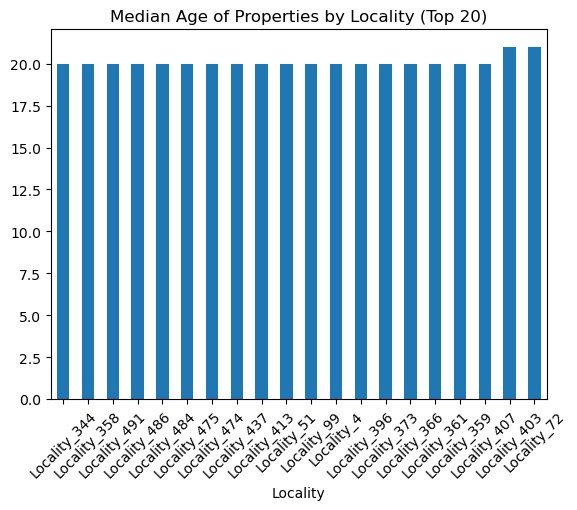

In [67]:
# 8. Median Property Age by Locality
df.groupby("Locality")["Age_of_Property"].median().sort_values().tail(20).plot(kind="bar")
plt.title("Median Age of Properties by Locality (Top 20)")
plt.xticks(rotation=45)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41]),
 [Text(0, 0, 'Ahmedabad'),
  Text(1, 0, 'Amritsar'),
  Text(2, 0, 'Bangalore'),
  Text(3, 0, 'Bhopal'),
  Text(4, 0, 'Bhubaneswar'),
  Text(5, 0, 'Bilaspur'),
  Text(6, 0, 'Chennai'),
  Text(7, 0, 'Coimbatore'),
  Text(8, 0, 'Cuttack'),
  Text(9, 0, 'Dehradun'),
  Text(10, 0, 'Durgapur'),
  Text(11, 0, 'Dwarka'),
  Text(12, 0, 'Faridabad'),
  Text(13, 0, 'Gaya'),
  Text(14, 0, 'Gurgaon'),
  Text(15, 0, 'Guwahati'),
  Text(16, 0, 'Haridwar'),
  Text(17, 0, 'Hyderabad'),
  Text(18, 0, 'Indore'),
  Text(19, 0, 'Jaipur'),
  Text(20, 0, 'Jamshedpur'),
  Text(21, 0, 'Jodhpur'),
  Text(22, 0, 'Kochi'),
  Text(23, 0, 'Kolkata'),
  Text(24, 0, 'Lucknow'),
  Text(25, 0, 'Ludhiana'),
  Text(26, 0, 'Mangalore'),
  Text(27, 0, 'Mumbai'),
  Text(28, 0, 'Mysore'),
  Text(29, 0, 'Nagpur'),
  Text(30, 0, 'New De

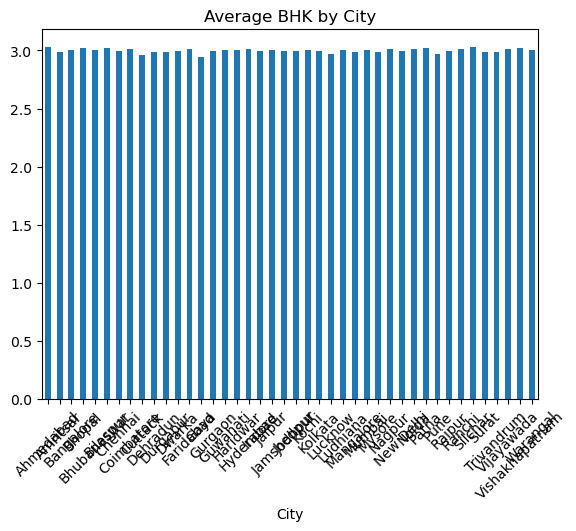

In [68]:
# 9. BHK Distribution Across Cities
df.groupby("City")["BHK"].mean().plot(kind="bar")
plt.title("Average BHK by City")
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Top 5 Most Expensive Localities')

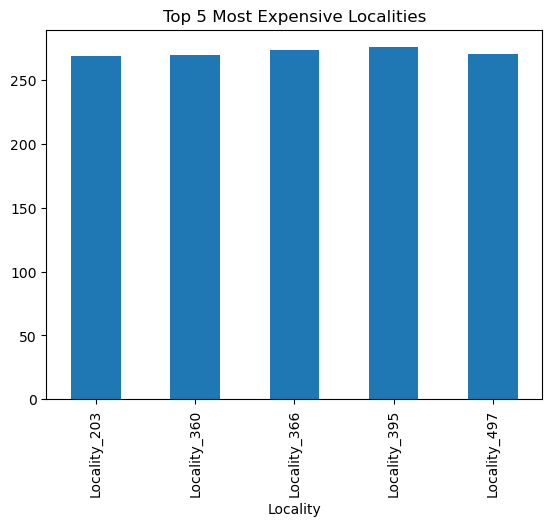

In [69]:
# 10. Price Trend – Top 5 Expensive Localities
top5 = df.groupby("Locality")["Price"].mean().sort_values().tail(5).index
df[df["Locality"].isin(top5)].groupby("Locality")["Price"].mean().plot(kind="bar")
plt.title("Top 5 Most Expensive Localities")

# Feature Relationship & Correlation


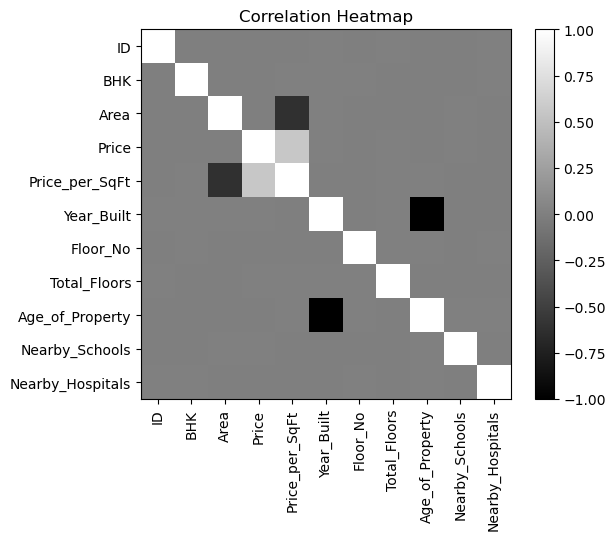

In [70]:
# 11. Feature Correlation Heatmap
corr = df.corr(numeric_only=True)
plt.imshow(corr, cmap="gray")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.colorbar()

In [ ]:
# 12. Nearby Schools vs Price per SqFt
plt.scatter(df["Nearby_Schools"], df["Price_per_SqFt"], s=10)
plt.title("Nearby Schools vs Price per SqFt")

Text(0.5, 1.0, 'Nearby Schools vs Price per SqFt')

Text(0.5, 1.0, 'Nearby Hospitals vs Price per SqFt')

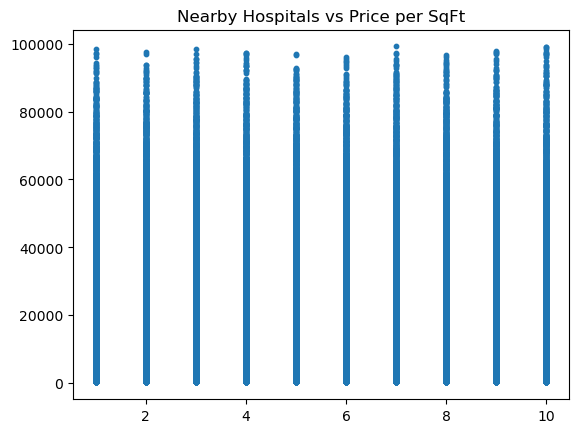

In [38]:
# 13. Hospitals vs Price per SqFt
plt.scatter(df["Nearby_Hospitals"], df["Price_per_SqFt"], s=10)
plt.title("Nearby Hospitals vs Price per SqFt")

Text(0.5, 1.0, 'Price by Furnished Status')

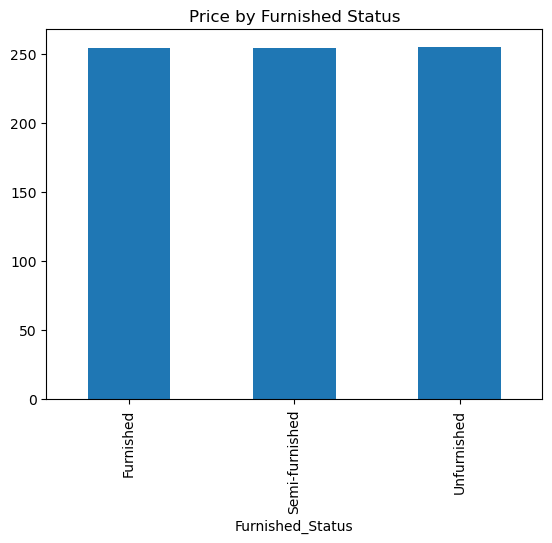

In [39]:
# 14. Price by Furnishing Status
df.groupby("Furnished_Status")["Price"].mean().plot(kind="bar")
plt.title("Price by Furnished Status")

(array([0, 1, 2, 3]),
 [Text(0, 0, 'East'),
  Text(1, 0, 'North'),
  Text(2, 0, 'South'),
  Text(3, 0, 'West')])

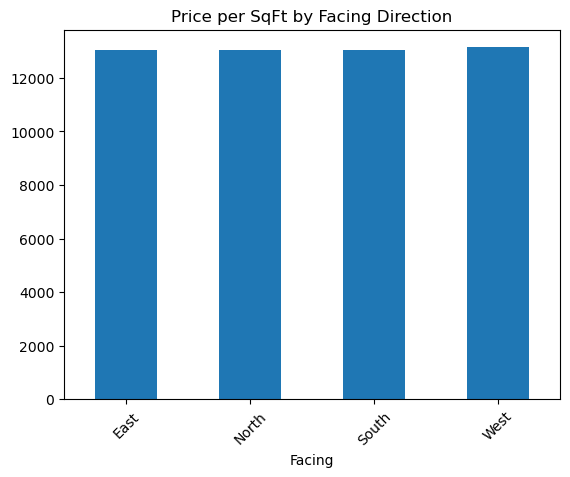

In [40]:
# 15. Price per SqFt by Facing Direction
df.groupby("Facing")["Price_per_SqFt"].mean().plot(kind="bar")
plt.title("Price per SqFt by Facing Direction")
plt.xticks(rotation=45)

# Investment / Amenities / Ownership Analysis

(array([0, 1, 2]),
 [Text(0, 0, 'Broker'), Text(1, 0, 'Owner'), Text(2, 0, 'Builder')])

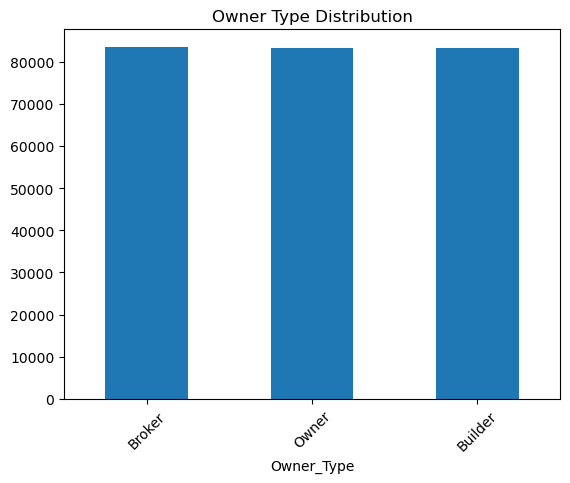

In [41]:
# 16. Owner Type Distribution
df["Owner_Type"].value_counts().plot(kind="bar")
plt.title("Owner Type Distribution")
plt.xticks(rotation=45)

(array([0, 1]),
 [Text(0, 0, 'Under_Construction'), Text(1, 0, 'Ready_to_Move')])

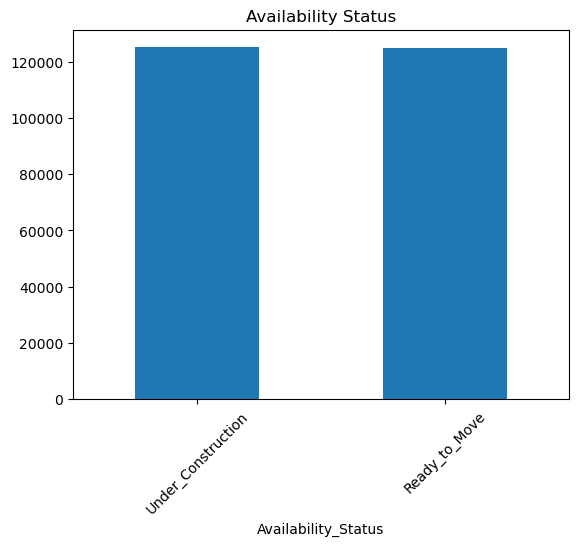

In [43]:
# 17. Availability Status Distribution
df["Availability_Status"].value_counts().plot(kind="bar")
plt.title("Availability Status")
plt.xticks(rotation=45)

Text(0.5, 1.0, 'Parking Space Impact on Price')

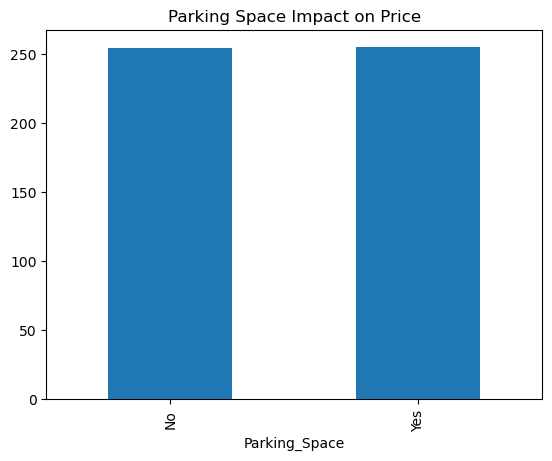

In [45]:
# 18. Parking vs Price
df.groupby("Parking_Space")["Price"].mean().plot(kind="bar")
plt.title("Parking Space Impact on Price")

Text(0.5, 1.0, 'Amenities Count vs Price per SqFt')

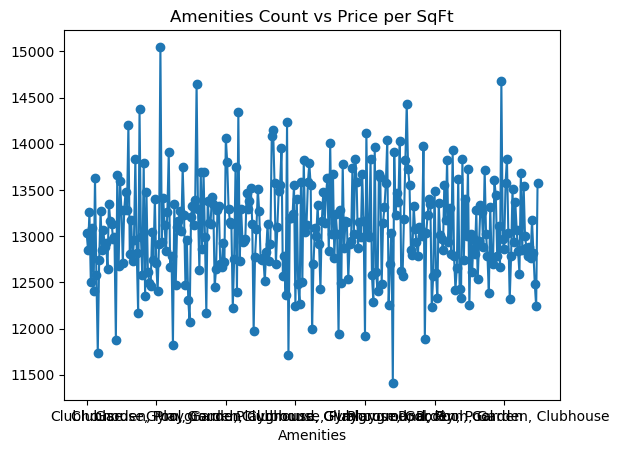

In [47]:
# 19. Amenities vs Price per SqFt
df.groupby("Amenities")["Price_per_SqFt"].mean().plot(kind="line", marker="o")
plt.title("Amenities Count vs Price per SqFt")

Text(0.5, 1.0, 'Public Transport vs Price per SqFt')

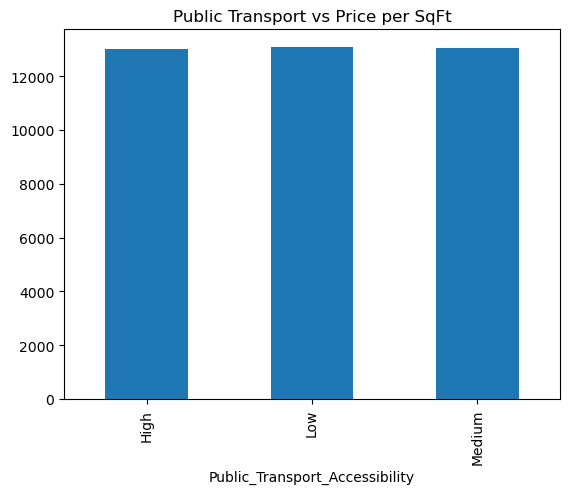

In [48]:
# 20. Transport Accessibility vs Investment Potential
df.groupby("Public_Transport_Accessibility")["Price_per_SqFt"].mean().plot(kind="bar")
plt.title("Public Transport vs Price per SqFt")



In [51]:
df.to_csv("cleaned_india_housing_prices.csv", index=False)

In [49]:
with open("EDA_Summary_Report.txt", "w") as f:
    f.write("===== EDA SUMMARY REPORT =====\n\n")
    f.write(str(df.describe()))
    f.write("\n\n===== Missing Values =====\n")
    f.write(str(df.isnull().sum()))
    f.write("\n\n===== Columns =====\n")
    f.write(str(df.columns.tolist()))
